# Analysis and Charts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv("medical_insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


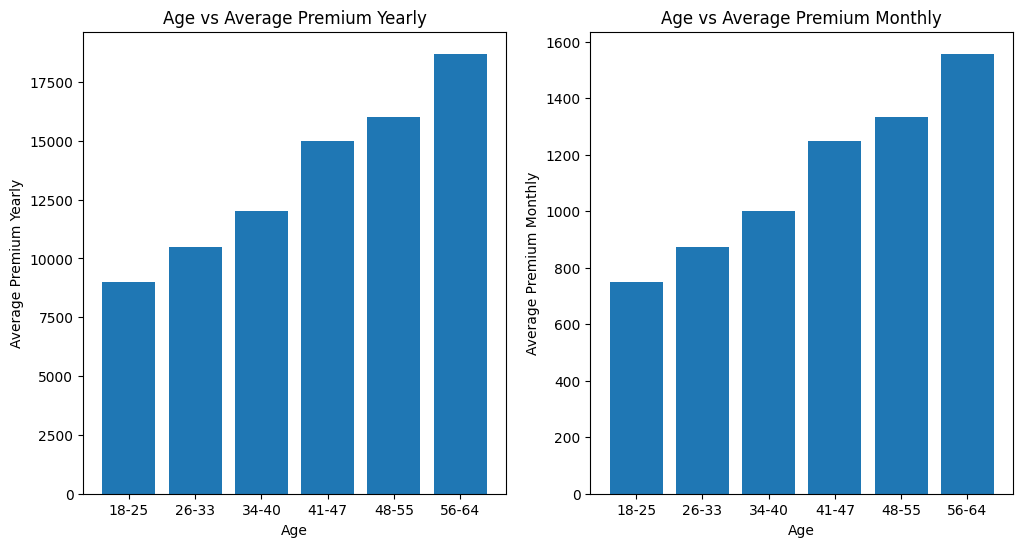

In [3]:
age_avg_premium = df.groupby(by=['age'])['charges'].sum()
age_avg_count = df.groupby(by=['age'])['charges'].count()

data = {
    '18-25': { 'min': 18, 'max': 25, 'charge': 0 },
    '26-33': { 'min': 26, 'max': 33, 'charge': 0 },
    '34-40': { 'min': 33, 'max': 40, 'charge': 0 },
    '41-47': { 'min': 41, 'max': 47, 'charge': 0 },
    '48-55': { 'min': 48, 'max': 55, 'charge': 0 },
    '56-64': { 'min': 56, 'max': 64, 'charge': 0 }
}


for age_group in data.keys():

    count = 0
    charge = 0
    
    min_age = data[age_group]['min']
    max_age = data[age_group]['max']

    for age in range(min_age, max_age+1):
        count += age_avg_count[age]
        charge += age_avg_premium[age]
    
    data[age_group]['count'] = round(count, -2)
    data[age_group]['cumulative'] = round(charge, -2)
    data[age_group]['charge'] = round(charge // count, -2)

counts = [ d['count'] for d in list(data.values()) ]
yearly = [ d['charge'] for d in list(data.values()) ]
monthly = [ d['charge'] // 12 for d in list(data.values()) ]

fig, ax = plt.subplots(1, 2, figsize=(12, 6) )

ax[0].bar(data.keys(), yearly )
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Average Premium Yearly")
ax[0].set_title("Age vs Average Premium Yearly")

ax[1].bar(data.keys(), monthly )
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Average Premium Monthly")
ax[1].set_title("Age vs Average Premium Monthly")
plt.show()

analysis = pd.DataFrame({
    'age': data.keys(), 'avg_yearly_premium': yearly, 'avg_monthly_premium': monthly, 'count': counts
})

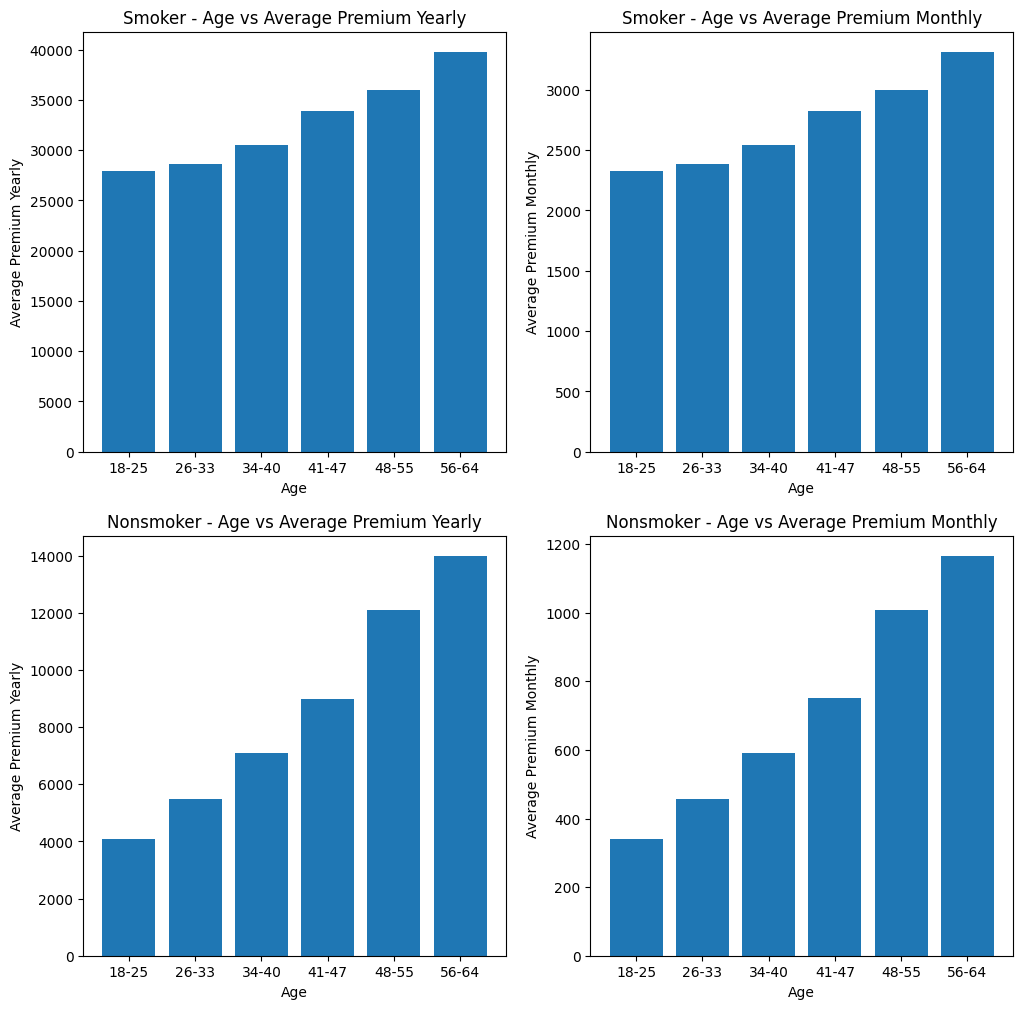

In [4]:
age_avg_premium = df.groupby(by=['smoker', 'age'])['charges'].sum()
age_avg_count = df.groupby(by=['smoker', 'age'])['charges'].count()

smoker_data_charge = age_avg_premium['yes']
nonsmoker_data_charge = age_avg_premium['no']

smoker_data_count = age_avg_count['yes']
nonsmoker_data_count = age_avg_count['no']

smoker_stats = {
    '18-25': { 'min': 18, 'max': 25, 'charge': 0 },
    '26-33': { 'min': 26, 'max': 33, 'charge': 0 },
    '34-40': { 'min': 33, 'max': 40, 'charge': 0 },
    '41-47': { 'min': 41, 'max': 47, 'charge': 0 },
    '48-55': { 'min': 48, 'max': 55, 'charge': 0 },
    '56-64': { 'min': 56, 'max': 64, 'charge': 0 }
}

nonsmoker_stats = {
    '18-25': { 'min': 18, 'max': 25, 'charge': 0 },
    '26-33': { 'min': 26, 'max': 33, 'charge': 0 },
    '34-40': { 'min': 33, 'max': 40, 'charge': 0 },
    '41-47': { 'min': 41, 'max': 47, 'charge': 0 },
    '48-55': { 'min': 48, 'max': 55, 'charge': 0 },
    '56-64': { 'min': 56, 'max': 64, 'charge': 0 }
}

for age_group in data.keys():

    # 0 for Smoker, 1 for Nonsmoker
    count = [0, 0]
    charge = [0, 0]

    # Same for both categories
    min_age = smoker_stats[age_group]['min']
    max_age = smoker_stats[age_group]['max']

    for age in range(min_age, max_age+1):
        count[0] += smoker_data_count[age]
        charge[0] += smoker_data_charge[age]

        count[1] += nonsmoker_data_count[age]
        charge[1] += nonsmoker_data_charge[age]
    
    smoker_stats[age_group]['count'] = round(count[0], -2)
    smoker_stats[age_group]['cumulative'] = round(charge[0], -2)
    smoker_stats[age_group]['charge'] = round(charge[0] // count[0], -2)

    nonsmoker_stats[age_group]['count'] = round(count[1], -2)
    nonsmoker_stats[age_group]['cumulative'] = round(charge[1], -2)
    nonsmoker_stats[age_group]['charge'] = round(charge[1] // count[1], -2)


# SMOKER 
counts = [ d['count'] for d in list(smoker_stats.values()) ]
yearly = [ d['charge'] for d in list(smoker_stats.values()) ]
monthly = [ d['charge'] // 12 for d in list(smoker_stats.values()) ]

fig, ax = plt.subplots(2, 2, figsize=(12, 12) )

ax[0][0].bar(smoker_stats.keys(), yearly )
ax[0][0].set_xlabel("Age")
ax[0][0].set_ylabel("Average Premium Yearly")
ax[0][0].set_title("Smoker - Age vs Average Premium Yearly")

ax[0][1].bar(smoker_stats.keys(), monthly )
ax[0][1].set_xlabel("Age")
ax[0][1].set_ylabel("Average Premium Monthly")
ax[0][1].set_title("Smoker - Age vs Average Premium Monthly")

analysis['smoker_count'] = counts
analysis['smoker_avg_yearly_premium'] = yearly
analysis['smoker_avg_monthly_premium'] = monthly

# NON SMOKER 
counts = [ d['count'] for d in list(nonsmoker_stats.values()) ]
yearly = [ d['charge'] for d in list(nonsmoker_stats.values()) ]
monthly = [ d['charge'] // 12 for d in list(nonsmoker_stats.values()) ]

ax[1][0].bar(nonsmoker_stats.keys(), yearly )
ax[1][0].set_xlabel("Age")
ax[1][0].set_ylabel("Average Premium Yearly")
ax[1][0].set_title("Nonsmoker - Age vs Average Premium Yearly")

ax[1][1].bar(nonsmoker_stats.keys(), monthly )
ax[1][1].set_xlabel("Age")
ax[1][1].set_ylabel("Average Premium Monthly")
ax[1][1].set_title("Nonsmoker - Age vs Average Premium Monthly")
plt.show()

analysis['nonsmoker_count'] = counts
analysis['nonsmoker_avg_yearly_premium'] = yearly
analysis['nonsmoker_avg_monthly_premium'] = monthly

In [5]:
analysis

,age,avg_yearly_premium,avg_monthly_premium,count,smoker_count,smoker_avg_yearly_premium,smoker_avg_monthly_premium,nonsmoker_count,nonsmoker_avg_yearly_premium,nonsmoker_avg_monthly_premium
0,18-25,9000.0,750.0,600,100,27900.0,2325.0,500,4100.0,341.0
1,26-33,10500.0,875.0,500,100,28600.0,2383.0,400,5500.0,458.0
2,34-40,12000.0,1000.0,400,100,30500.0,2541.0,300,7100.0,591.0
3,41-47,15000.0,1250.0,400,100,33900.0,2825.0,300,9000.0,750.0
4,48-55,16000.0,1333.0,500,100,36000.0,3000.0,400,12100.0,1008.0
5,56-64,18700.0,1558.0,400,100,39800.0,3316.0,400,14000.0,1166.0


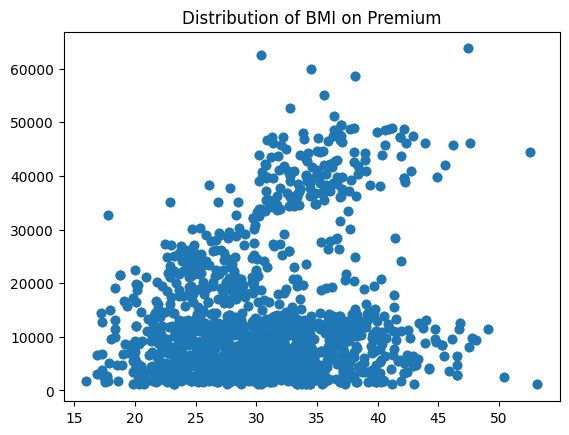

In [6]:
# For normal user trash 
plt.scatter(df['bmi'], df['charges'])
plt.title("Distribution of BMI on Premium")
plt.show()

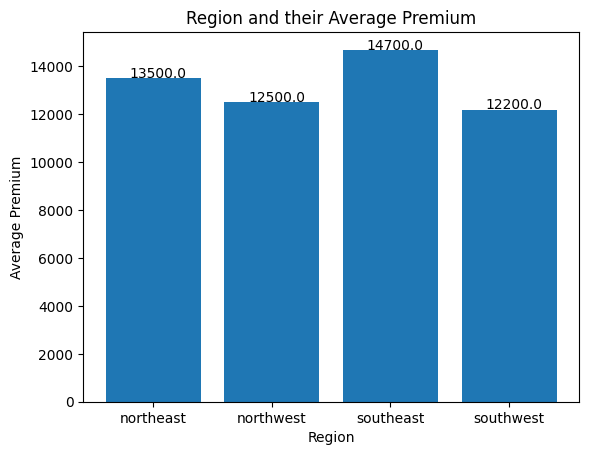

In [7]:
region_premium = df.groupby(by=['region'])['charges'].mean()
region = pd.DataFrame({
    'region': region_premium.index, 'avg_premium': [ round(premium, -2) for premium in region_premium.values ]   
})

bars = plt.bar(region_premium.index, [ round(premium, -2) for premium in region_premium.values ])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 4, bar.get_height() + 15, bar.get_height())

plt.xlabel("Region")
plt.ylabel("Average Premium")
plt.title("Region and their Average Premium")
plt.show()

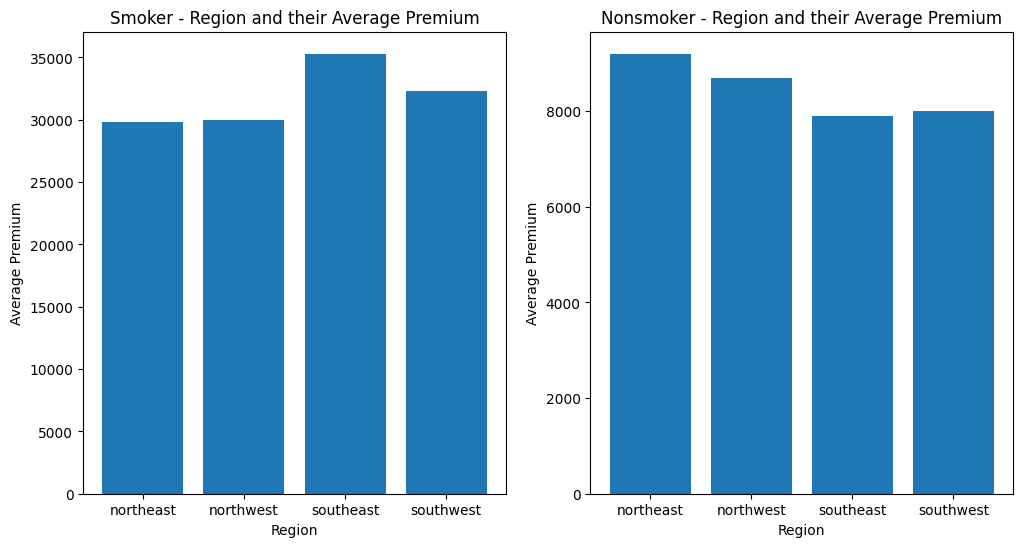

In [8]:
region_premium = df.groupby(by=['smoker', 'region'])['charges'].mean()

smoker_premium = region_premium['yes']
nonsmoker_premium = region_premium['no']

region['smoker_avg_premium'] = [ round(premium, -2) for premium in smoker_premium.values ]
region['nonsmoker_avg_premium'] = [ round(premium, -2) for premium in nonsmoker_premium.values ]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].bar(smoker_premium.index, [ round(premium, -2) for premium in smoker_premium.values ])
ax[0].set_xlabel("Region")
ax[0].set_ylabel("Average Premium")
ax[0].set_title("Smoker - Region and their Average Premium")

ax[1].bar(nonsmoker_premium.index, [ round(premium, -2) for premium in nonsmoker_premium.values ])
ax[1].set_xlabel("Region")
ax[1].set_ylabel("Average Premium")
ax[1].set_title("Nonsmoker - Region and their Average Premium")


plt.show()

In [9]:
region

,region,avg_premium,smoker_avg_premium,nonsmoker_avg_premium
0,northeast,13500.0,29800.0,9200.0
1,northwest,12500.0,30000.0,8700.0
2,southeast,14700.0,35300.0,7900.0
3,southwest,12200.0,32300.0,8000.0
